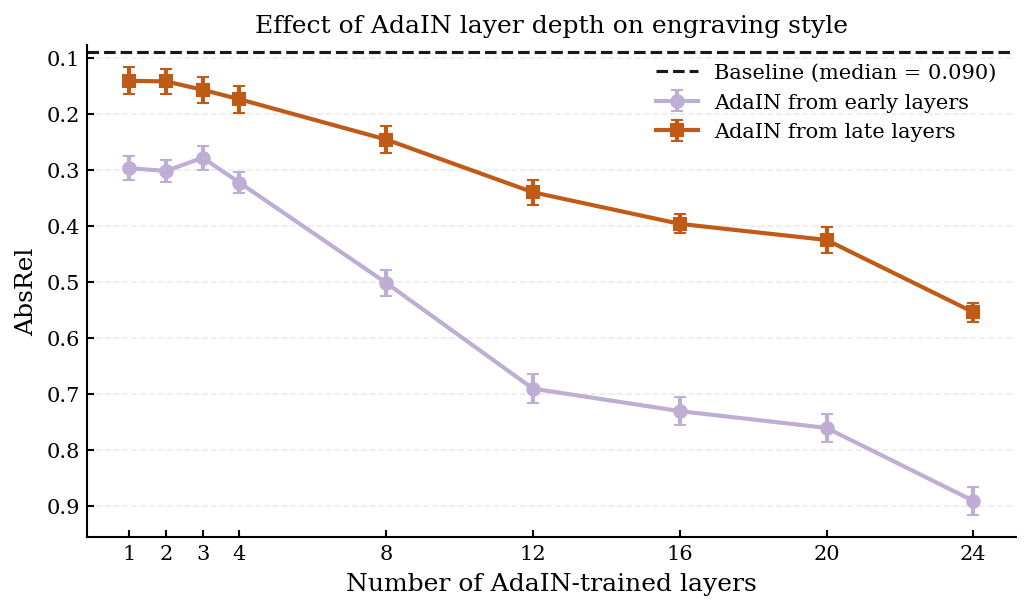

In [ ]:


import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif"],
    "mathtext.fontset": "cm",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})


# --------------------------------------------------
# Configuration & Data Loading
# --------------------------------------------------
RESULTS_DIR = Path("evaluation_results")
CACHE_CSV_PATH = RESULTS_DIR / "adain_results.csv"

STATISTIC = "MEDIAN"
METRIC = "AbsRel"
SAVE_FIGURE = False
OUTPUT_NAME = f"engraving_adain_{METRIC}_{STATISTIC}_inverted.pdf"

BASELINE_VALUES = {"MEAN": 0.121809, "MEDIAN": 0.089751}
BASELINE_VALUE = BASELINE_VALUES[STATISTIC]

# Load the saved CSV data
if not CACHE_CSV_PATH.exists():
    raise FileNotFoundError(f"Could not find cached file at {CACHE_CSV_PATH}. Make sure it was exported correctly.")

df_cached = pd.read_csv(CACHE_CSV_PATH)

# Extract counts for the ticks
LAYER_COUNTS = df_cached["layer_count"].tolist()

# --------------------------------------------------
# Plot
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(7.0, 4.2))

# Better research-style colors
cmap = plt.get_cmap("Accent")

forward_color = cmap(0.15)
backward_color = cmap(0.75)
baseline_color = "black"

# Forward training
ax.errorbar(
    df_cached["layer_count"],
    df_cached["forward_value"],
    yerr=df_cached["forward_sem"],
    marker='o',
    linewidth=2,
    capsize=3,
    color=forward_color,
    markersize=6,
    label="AdaIN from early layers"
)

# End-layer training
ax.errorbar(
    df_cached["layer_count"],
    df_cached["backward_value"],
    yerr=df_cached["backward_sem"],
    marker='s',
    linewidth=2,
    capsize=3,
    color=backward_color,
    markersize=6,
    label="AdaIN from late layers"
)

# --------------------------------------------------
# Baseline reference
# --------------------------------------------------

ax.axhline(
    BASELINE_VALUE,
    linestyle="--",
    linewidth=1.5,
    alpha=0.9,
    color=baseline_color,
    label=f"Baseline ({STATISTIC.lower()} = {BASELINE_VALUE:.3f})"
)

# --------------------------------------------------
# Formatting
# --------------------------------------------------

ax.set_xlabel("Number of AdaIN-trained layers")
ax.set_ylabel(METRIC)
ax.set_title("Effect of AdaIN layer depth on engraving style")
ax.set_xticks(LAYER_COUNTS)

# Invert y-axis
# Lower error values appear visually higher
ax.invert_yaxis()

# Scientific cleanup
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.legend(
    frameon=False
)

plt.tight_layout()

# --------------------------------------------------
# Save
# --------------------------------------------------
if SAVE_FIGURE:
    plt.savefig(
        OUTPUT_NAME,
        bbox_inches="tight",
        transparent=True
    )
    print(f"Saved plot to {OUTPUT_NAME}")

plt.show()